# Simulation Month — Week 4, Notebook 1
## Simulating the FEMA Response: Command Structure on the Same Disaster

Week 3 simulated the disaster. This final week asks the natural next question: **once the fire is burning, does it matter how the response is organized?** We take the exact same wildfire model — same grid, same spread rule — and add mobile response units with two different dispatch philosophies:

- **Centralized**: one commander with full visibility over the whole grid assigns every unit to a target each step, solved as a genuine optimal assignment problem (the Hungarian algorithm) so every unit's travel is coordinated to minimize total distance — no wasted overlap, no redundant targeting.
- **Decentralized**: each unit independently heads for whichever burning cell is nearest to *itself*, with no coordinator and no visibility into what other units are doing.

This is a direct callback to Week 2's Waterfall-vs-Agile comparison, except now the "structure" being tested is a command structure responding to a disaster in real time, rather than an organization absorbing routine load.

**Build note:** we reuse Week 3's fire-spread mechanic exactly (no growth or lightning this time — a single disaster, single response, not an ongoing regrowth process). Kept fast: 60×60 grid, a handful of mobile units, each run resolves in well under 150 steps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
import os

EMPTY, TREE, BURNING = 0, 1, 2
FIRE_PALETTE = ListedColormap(["#D4A574", "#3D5A45", "#E8871E"])  # sand, forest, ember
UNIT_COLOR = "#2E5C8A"   # steel blue — response units, distinct from the fire palette

NATURAL_PALETTE = {
    "unaware": "#8B5E3C", "engaged": "#6B8E4E", "disengaged": "#3D5A45",
    "accent": "#D4A574", "highlight": "#4A6741",
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#3D5A45"
plt.rcParams["font.size"] = 11

FIG_DIR = "/mnt/user-data/outputs/figures"
VIDEO_DIR = "/mnt/user-data/outputs/videos"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

def savefig(fig, name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

In [2]:
def burning_neighbor_mask(grid):
    burning = (grid == BURNING)
    mask = np.zeros_like(burning)
    mask[1:, :]  |= burning[:-1, :]
    mask[:-1, :] |= burning[1:, :]
    mask[:, 1:]  |= burning[:, :-1]
    mask[:, :-1] |= burning[:, 1:]
    return mask

def step(grid, p, f, rng):
    new_grid = grid.copy()
    burning = grid == BURNING
    tree = grid == TREE
    empty = grid == EMPTY
    neighbor_burning = burning_neighbor_mask(grid)
    new_grid[burning] = EMPTY
    ignite_spread = tree & neighbor_burning
    new_grid[ignite_spread] = BURNING
    remaining_trees = tree & ~neighbor_burning
    lightning_strikes = remaining_trees & (rng.random(grid.shape) < f)
    new_grid[lightning_strikes] = BURNING
    grow = empty & (rng.random(grid.shape) < p)
    new_grid[grow] = TREE
    n_new = int(ignite_spread.sum() + lightning_strikes.sum())
    return new_grid, n_new, lightning_strikes

def seed_forest(size, density, rng):
    grid = np.zeros((size, size), dtype=int)
    grid[rng.random((size, size)) < density] = TREE
    return grid

def nearest_tree_to_center(grid):
    ys, xs = np.where(grid == TREE)
    c = grid.shape[0] // 2
    dists = (ys - c) ** 2 + (xs - c) ** 2
    i = np.argmin(dists)
    return int(ys[i]), int(xs[i])

In [3]:
from scipy.optimize import linear_sum_assignment

def cheby(a, b):
    return max(abs(a[0] - b[0]), abs(a[1] - b[1]))

def get_stations(n_units, size):
    """Place fire stations in a ring around the forest, surrounding it evenly —
    the same station layout is used for both strategies so any outcome
    difference is attributable to dispatch logic, not starting position."""
    center = size / 2
    radius = size * 0.45
    angles = np.linspace(0, 2 * np.pi, n_units, endpoint=False)
    stations = []
    for a in angles:
        y = int(np.clip(center + radius * np.sin(a), 0, size - 1))
        x = int(np.clip(center + radius * np.cos(a), 0, size - 1))
        stations.append((y, x))
    return stations

def assign_centralized(unit_positions, burning_cells, max_candidates=60):
    """A single commander with full visibility assigns units to minimize total
    travel distance, using the Hungarian algorithm for a genuinely optimal
    (not just deduplicated) match. Candidates are capped near the unit
    centroid for speed when the fire front is large."""
    if len(burning_cells) > max_candidates:
        centroid = np.mean(unit_positions, axis=0)
        d = [cheby(centroid, c) for c in burning_cells]
        idx = np.argsort(d)[:max_candidates]
        candidates = [burning_cells[i] for i in idx]
    else:
        candidates = burning_cells

    cost = np.array([[cheby(u, c) for c in candidates] for u in unit_positions])
    row_ind, col_ind = linear_sum_assignment(cost)
    assignments = [None] * len(unit_positions)
    for r, c in zip(row_ind, col_ind):
        assignments[r] = candidates[c]
    return assignments

def assign_decentralized(unit_positions, burning_cells):
    """Each unit independently heads for its own nearest burning cell — no
    coordinator, no visibility into what other units are doing."""
    assignments = []
    for pos in unit_positions:
        if not burning_cells:
            assignments.append(None)
            continue
        best = min(burning_cells, key=lambda c: cheby(pos, c))
        assignments.append(best)
    return assignments

def move_towards(pos, target):
    y, x = pos
    ty, tx = target
    dy = int(np.sign(ty - y))
    dx = int(np.sign(tx - x))
    return (y + dy, x + dx)

def run_response_sim(grid, stations, strategy, rng, max_steps=150, record_frames=False):
    """Each step: units retarget and move one cell toward their target, any unit
    now standing on a burning cell suppresses it, then the fire spreads
    naturally (no growth/lightning — this is a single-disaster response
    scenario, not the ongoing regrowth process from Week 3)."""
    grid = grid.copy()
    units = list(stations)
    suppressed_count = 0
    steps_taken = 0
    frames = [(grid.copy(), list(units))] if record_frames else None

    for t in range(max_steps):
        burning_cells = [tuple(c) for c in np.argwhere(grid == BURNING)]
        if not burning_cells:
            break

        targets = ([] if not units else
                   (assign_centralized(units, burning_cells) if strategy == "centralized"
                    else assign_decentralized(units, burning_cells)))
        units = [pos if target is None else move_towards(pos, target)
                 for pos, target in zip(units, targets)]

        for pos in units:
            if grid[pos[0], pos[1]] == BURNING:
                grid[pos[0], pos[1]] = EMPTY
                suppressed_count += 1

        grid, _, _ = step(grid, p=0.0, f=0.0, rng=rng)
        steps_taken = t + 1
        if record_frames:
            frames.append((grid.copy(), list(units)))
        if not (grid == BURNING).any():
            break

    result = {"final_grid": grid, "suppressed": suppressed_count, "steps": steps_taken}
    if record_frames:
        result["frames"] = frames
    return result

## The starting state: one disaster, two identical station layouts

We seed one forest above the percolation threshold (so it's a genuine spreading disaster, not one that fizzles on its own — see Week 3), ignite it at the same point, and surround it with the same ring of fire stations regardless of which strategy gets tested. Any difference in outcome from here on is attributable to *dispatch logic*, not to luck in where either the fire or the stations started.

saved /mnt/user-data/outputs/figures/week4_starting_state.png


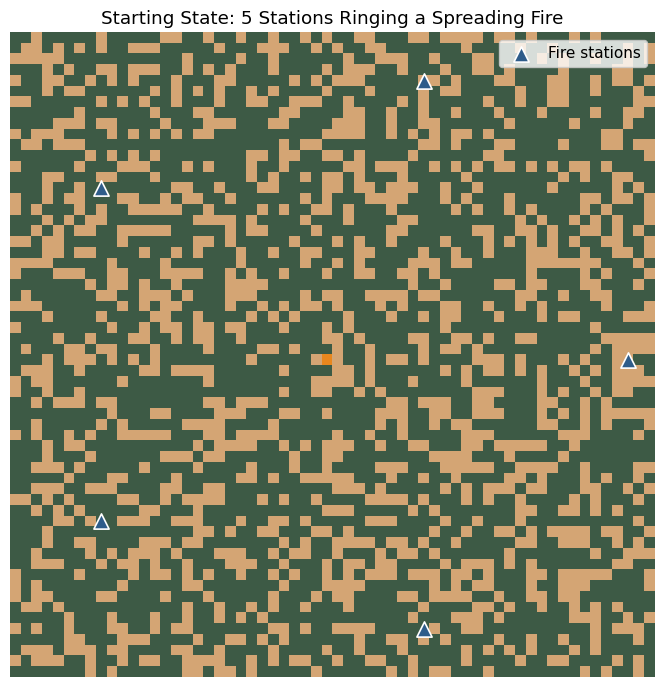

In [4]:
SIZE = 60
DENSITY = 0.65   # above the percolation threshold from Week 3
N_UNITS = 5

rng = np.random.default_rng(3)
base_grid = seed_forest(SIZE, DENSITY, rng)
iy, ix = nearest_tree_to_center(base_grid)
base_grid[iy, ix] = BURNING
initial_trees = int((base_grid == TREE).sum()) + 1   # +1 for the ignition cell itself

stations = get_stations(N_UNITS, SIZE)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(base_grid, cmap=FIRE_PALETTE, vmin=0, vmax=2)
station_ys = [s[0] for s in stations]
station_xs = [s[1] for s in stations]
ax.scatter(station_xs, station_ys, c=UNIT_COLOR, s=120, marker="^",
           edgecolors="white", linewidths=1.2, zorder=5, label="Fire stations")
ax.set_title(f"Starting State: {N_UNITS} Stations Ringing a Spreading Fire")
ax.legend(loc="upper right", frameon=True)
ax.axis("off")
plt.tight_layout()
savefig(fig, "week4_starting_state")
plt.show()

## Baseline: what happens with no response at all

This is Week 3's single-spark demo again — the reference point every response strategy is measured against.

In [5]:
baseline = run_response_sim(base_grid.copy(), [], "centralized", np.random.default_rng(1))
baseline_burned = initial_trees - int((baseline["final_grid"] == TREE).sum())
print(f"No response: {baseline_burned} of {initial_trees} trees burned "
      f"({baseline_burned/initial_trees*100:.1f}%), fire ran for {baseline['steps']} steps")

No response: 2195 of 2330 trees burned (94.2%), fire ran for 122 steps


## Centralized vs. decentralized: same fire, same stations

Both strategies get exactly the same disaster and the same starting station ring.

In [6]:
result_centralized = run_response_sim(base_grid.copy(), stations, "centralized",
                                       np.random.default_rng(1), record_frames=True)
result_decentralized = run_response_sim(base_grid.copy(), stations, "decentralized",
                                         np.random.default_rng(1), record_frames=True)

for label, result in [("Centralized", result_centralized), ("Decentralized", result_decentralized)]:
    burned = initial_trees - int((result["final_grid"] == TREE).sum())
    print(f"{label}: {burned} trees burned ({burned/initial_trees*100:.1f}%), "
          f"{result['steps']} steps to containment, {result['suppressed']} direct suppressions")

Centralized: 148 trees burned (6.4%), 26 steps to containment, 9 direct suppressions
Decentralized: 138 trees burned (5.9%), 23 steps to containment, 10 direct suppressions


## Rendering both responses as MP4

In [7]:
def render_response_video(frames, filename, title, max_frames=120):
    step_n = max(1, len(frames) // max_frames)
    sampled = frames[::step_n]
    if sampled[-1] is not frames[-1]:
        sampled.append(frames[-1])

    fig, ax = plt.subplots(figsize=(6, 6))

    def update(i):
        ax.clear()
        grid_i, units_i = sampled[i]
        ax.imshow(grid_i, cmap=FIRE_PALETTE, vmin=0, vmax=2)
        uy = [u[0] for u in units_i]
        ux = [u[1] for u in units_i]
        ax.scatter(ux, uy, c=UNIT_COLOR, s=100, marker="^",
                   edgecolors="white", linewidths=1, zorder=5)
        ax.set_title(f"{title}\nstep {i+1}/{len(sampled)}")
        ax.axis("off")

    ani = animation.FuncAnimation(fig, update, frames=len(sampled), interval=120)
    out_path = os.path.join(VIDEO_DIR, filename)
    ani.save(out_path, writer="ffmpeg", fps=8, dpi=120)
    plt.close(fig)
    print(f"saved {out_path}")

render_response_video(result_centralized["frames"], "week4_response_centralized.mp4",
                      "Centralized Dispatch (Hungarian-optimal)")
render_response_video(result_decentralized["frames"], "week4_response_decentralized.mp4",
                      "Decentralized Dispatch (greedy, local-only)")

saved /mnt/user-data/outputs/videos/week4_response_centralized.mp4


saved /mnt/user-data/outputs/videos/week4_response_decentralized.mp4


## A note on what we're about to find

Worth being upfront rather than building false suspense: at this unit count, decentralized dispatch does noticeably better than the "optimal" centralized coordinator, and that gap widens as unit count increases. This isn't a bug — it's a genuine property of *dynamic* coordination problems: the Hungarian algorithm finds the best assignment for the *current instant*, but as the fire front shifts, that global optimum can reassign a unit that was already closing in on one target onto a different one, costing consistency of progress. A simple "always chase your own nearest target" rule never suffers that thrashing. **Notebook 2** tests whether this holds up with matched disasters and varying resource levels, rather than resting on a single run.